## Chapter 3 - Applied

Let's review some key formulas from this chapter before moving on to the exercises.
<br></br>

**Standard Error**

$$
SE(\hat{\mu}) = \frac{\sigma}{\sqrt{n}}
$$

**Residual Standard Error**

$$
RSE = \sqrt{ \left( \frac{RSS}{n-k} \right) }
$$

**Hypothesis Test - Coefficient**

$$
H_0: \beta_1 = 0
$$
$$
H_a: \beta_1 \neq 0
$$
$$
t = \frac{\hat{\beta_1} - 0}{SE(\hat{\beta_1})}
$$

$\boldsymbol{R^2}$

$$
R^2 = 1 - \frac{RSS}{TSS}
$$

$$
TSS = \sum_{i=1}^n (y_i - \bar{y})^2
$$

$$
RSS = \sum_{i=1}^n (y_i - \hat{y})^2
$$

**Correlation**

$$
Cor(X,Y) = \frac{\sum_{i=1}^n (x_i - \bar{x}) (y_i - \bar{y})}
    {\sigma_x  \sigma_y}
$$
<br></br>

### Question 8

In [317]:
# Imports
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF
from statsmodels.stats.anova import anova_lm
from sklearn.preprocessing import PolynomialFeatures
from IPython.display import display, Markdown

# Imports to recreate poly() from R
from scipy import odr # orthogonal distance regression
from ISLP.models import ModelSpec as MS, summarize, poly
from scipy.special import assoc_laguerre, eval_legendre, eval_chebyt
from numpy.linalg import qr

#### 8a)

In [318]:
# Load dataset
auto = pd.read_csv('data/Auto.csv')
auto.columns = [x.lower() for x in auto.columns]

# Check quick info
auto.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 397 entries, 0 to 396
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           397 non-null    float64
 1   cylinders     397 non-null    int64  
 2   displacement  397 non-null    float64
 3   horsepower    397 non-null    object 
 4   weight        397 non-null    int64  
 5   acceleration  397 non-null    float64
 6   year          397 non-null    int64  
 7   origin        397 non-null    int64  
 8   name          397 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.0+ KB


In [319]:
# Check first observations
auto.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [320]:
# Check unique values for 'horsepower'
np.unique(auto['horsepower'])

array(['100', '102', '103', '105', '107', '108', '110', '112', '113',
       '115', '116', '120', '122', '125', '129', '130', '132', '133',
       '135', '137', '138', '139', '140', '142', '145', '148', '149',
       '150', '152', '153', '155', '158', '160', '165', '167', '170',
       '175', '180', '190', '193', '198', '200', '208', '210', '215',
       '220', '225', '230', '46', '48', '49', '52', '53', '54', '58',
       '60', '61', '62', '63', '64', '65', '66', '67', '68', '69', '70',
       '71', '72', '74', '75', '76', '77', '78', '79', '80', '81', '82',
       '83', '84', '85', '86', '87', '88', '89', '90', '91', '92', '93',
       '94', '95', '96', '97', '98', '?'], dtype=object)

In [321]:
# Remove '?' and adapt data type
auto = auto[auto['horsepower'] != '?']
auto['horsepower'] = auto['horsepower'].astype('int')

In [322]:
# Create feature matrix & response variable
X = pd.DataFrame({
    'intercept': np.ones(auto.shape[0]),
    'horsepower': auto['horsepower']
})
y = auto['mpg']

# Create & fit model
model = sm.OLS(endog=y, exog=X)
results = model.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    mpg   R-squared:                       0.606
Model:                            OLS   Adj. R-squared:                  0.605
Method:                 Least Squares   F-statistic:                     599.7
Date:                Wed, 27 May 2026   Prob (F-statistic):           7.03e-81
Time:                        14:36:32   Log-Likelihood:                -1178.7
No. Observations:                 392   AIC:                             2361.
Df Residuals:                     390   BIC:                             2369.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     39.9359      0.717     55.660      0.000      38.525      41.347
horsepower    -0.1578      0.006    -24.489      0.000      -0.171      -0.145
==============================================================================
Omnibus:                       16.432   Durbin-Watson:                   0.920
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               17.305
Skew:                           0.492   Prob(JB):                     0.000175
Kurtosis:                       3.299   Cond. No.                         322.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

**i)** There is a statistically significant relationship between 'mpg' and 'horsepower', as indicated by both the t-statistic of the 'horsepower' coefficient and the model's F-statistic.

The t-test reject the null hypothesis that the coefficient 'horsepower' is 0, while the F-test rejects the null hypothesis that the model does not explain the variation in 'mpg'.


In [323]:
# Compute Sum of Squared Residuals (RSS)
y_hat = results.predict(X)
rss = sum((y - y_hat)**2)

# Compute Residual Standard Error (RSE)
n = len(y_hat)
k = 2 # B0, B1
rse = np.sqrt(rss / (n - 2))

# Get R2
r2 = results.rsquared

# Percentage error
perc_error = rse/y.mean()

# Markdown style to match jupyter's
style = """
<style>
.custom-md {
    font-size: 16px;
    line-height: 1.6;
    font-family: "Helvetica", "Arial", sans-serif;
}
</style>
"""

# Answer in markdown
answer_ii = f"""
**ii)** The model provides a percentage of error of {perc_error:.2%}, calculated 
using a mean response value of {y.mean():.2f} and a RSE of {rse:.2f}. Additionally, 
the $R^2$ value is {r2:.2f}, indicating that approximately {r2:.2%} of the variance 
in the response variable is explained by the model. Together, these metrics suggest 
a statistically significant relationship between the predictors and the response.
"""
display(Markdown(answer_ii))


**ii)** The model provides a percentage of error of 20.92%, calculated 
using a mean response value of 23.45 and a RSE of 4.91. Additionally, 
the $R^2$ value is 0.61, indicating that approximately 60.59% of the variance 
in the response variable is explained by the model. Together, these metrics suggest 
a statistically significant relationship between the predictors and the response.


**iii)** Given the coefficient of -0.1578 for 
'horsepower', we can affirm that the predictor has 
a negative relationship with the response.

In [324]:
results.conf_int()

,0,1
intercept,38.525212,41.346510
horsepower,-0.170517,-0.145172


In [325]:
# Predict on new observation
observation = np.array((1, 98))
observation_pred = results.get_prediction(observation)

# Confidence Interval (CI)
observation_pred_ci = observation_pred.conf_int(alpha=0.05)
observation_pred_ci = observation_pred_ci.flatten()
observation_pred_ci = [round(x, 2) for x in observation_pred_ci]

# Prediction Interval
observation_pred_pi = observation_pred.conf_int(obs=True, alpha=0.05)
observation_pred_pi = observation_pred_pi.flatten()
observation_pred_pi = [round(x, 2) for x in observation_pred_pi]

answer_iv = f"""
<div class="custom-md">

**iv)** Given that 98 is the 'horsepower' in each 
car, the **confidence interval** (CI) is {observation_pred_ci}. 
If a particular car has 98 'horsepower' the 
**prediction interval** is {observation_pred_pi}.

The **prediction interval** is considerably wider 
than the **confidence interval** due to the increased 
uncertainty about 'mpg' for a given car in comparison 
to the average 'mpg' over many cars.

</div>
"""

display(Markdown(style + answer_iv))


<style>
.custom-md {
    font-size: 16px;
    line-height: 1.6;
    font-family: "Helvetica", "Arial", sans-serif;
}
</style>

<div class="custom-md">

**iv)** Given that 98 is the 'horsepower' in each 
car, the **confidence interval** (CI) is [23.97, 24.96]. 
If a particular car has 98 'horsepower' the 
**prediction interval** is [14.81, 34.12].

The **prediction interval** is considerably wider 
than the **confidence interval** due to the increased 
uncertainty about 'mpg' for a given car in comparison 
to the average 'mpg' over many cars.

</div>


In [326]:
# Manually computing PI
rss = sum((y - y_hat)**2)
rse = np.sqrt(rss / (len(y) - X.shape[1]))
pred = results.predict(np.array((1, 98))).item()
critical_value = 1.966 # t_(0.025, 390)
upper_band = round(pred + (critical_value * rse), 2)
lower_band = round(pred - (critical_value * rse), 2)
lower_band, upper_band

(14.82, 34.11)

#### 8b)

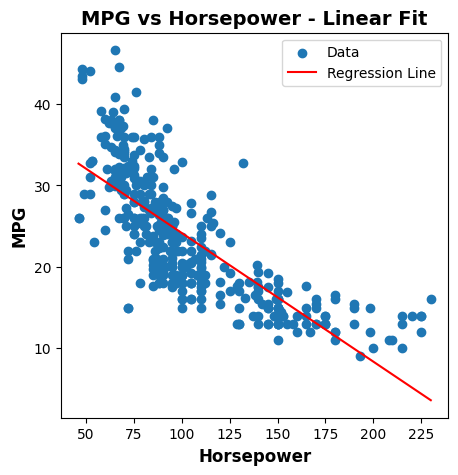

In [327]:
# Create a data range
data_min = X['horsepower'].min()
data_max = X['horsepower'].max()
data_range = np.linspace(data_min, data_max, 100)
data_pred = np.column_stack((np.ones(100), data_range))
pred = results.predict(data_pred)

# Plots arguments
title_args = {
    'fontsize': 14,
    'fontweight': 'bold'
}
label_args = {
    'fontsize': 12,
    'fontweight': 'bold'
}

# Plot data + regression
plt.figure(figsize=(5, 5))
plt.scatter(X['horsepower'], y, label='Data')
plt.plot(data_range, pred, color='red', label='Regression Line')
plt.xlabel('Horsepower', **label_args)
plt.ylabel('MPG', **label_args)
plt.title('MPG vs Horsepower - Linear Fit', **title_args)
plt.legend()
plt.show()

#### 8c)

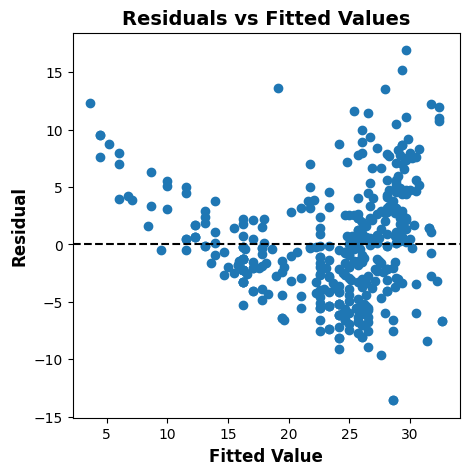

In [328]:
# Plot the residuals
residuals = (y - y_hat)
plt.figure(figsize=(5,5))
plt.scatter(y_hat, residuals)
plt.axhline(0, c='k', ls='--')
plt.xlabel('Fitted Value', **label_args)
plt.ylabel('Residual', **label_args)
plt.title('Residuals vs Fitted Values', **title_args);

The plot reveals evidence of non-linearity and heteroscedasticity, as the residual variance appears to increase with higher fitted values.

---

### Question 9

#### 9a)

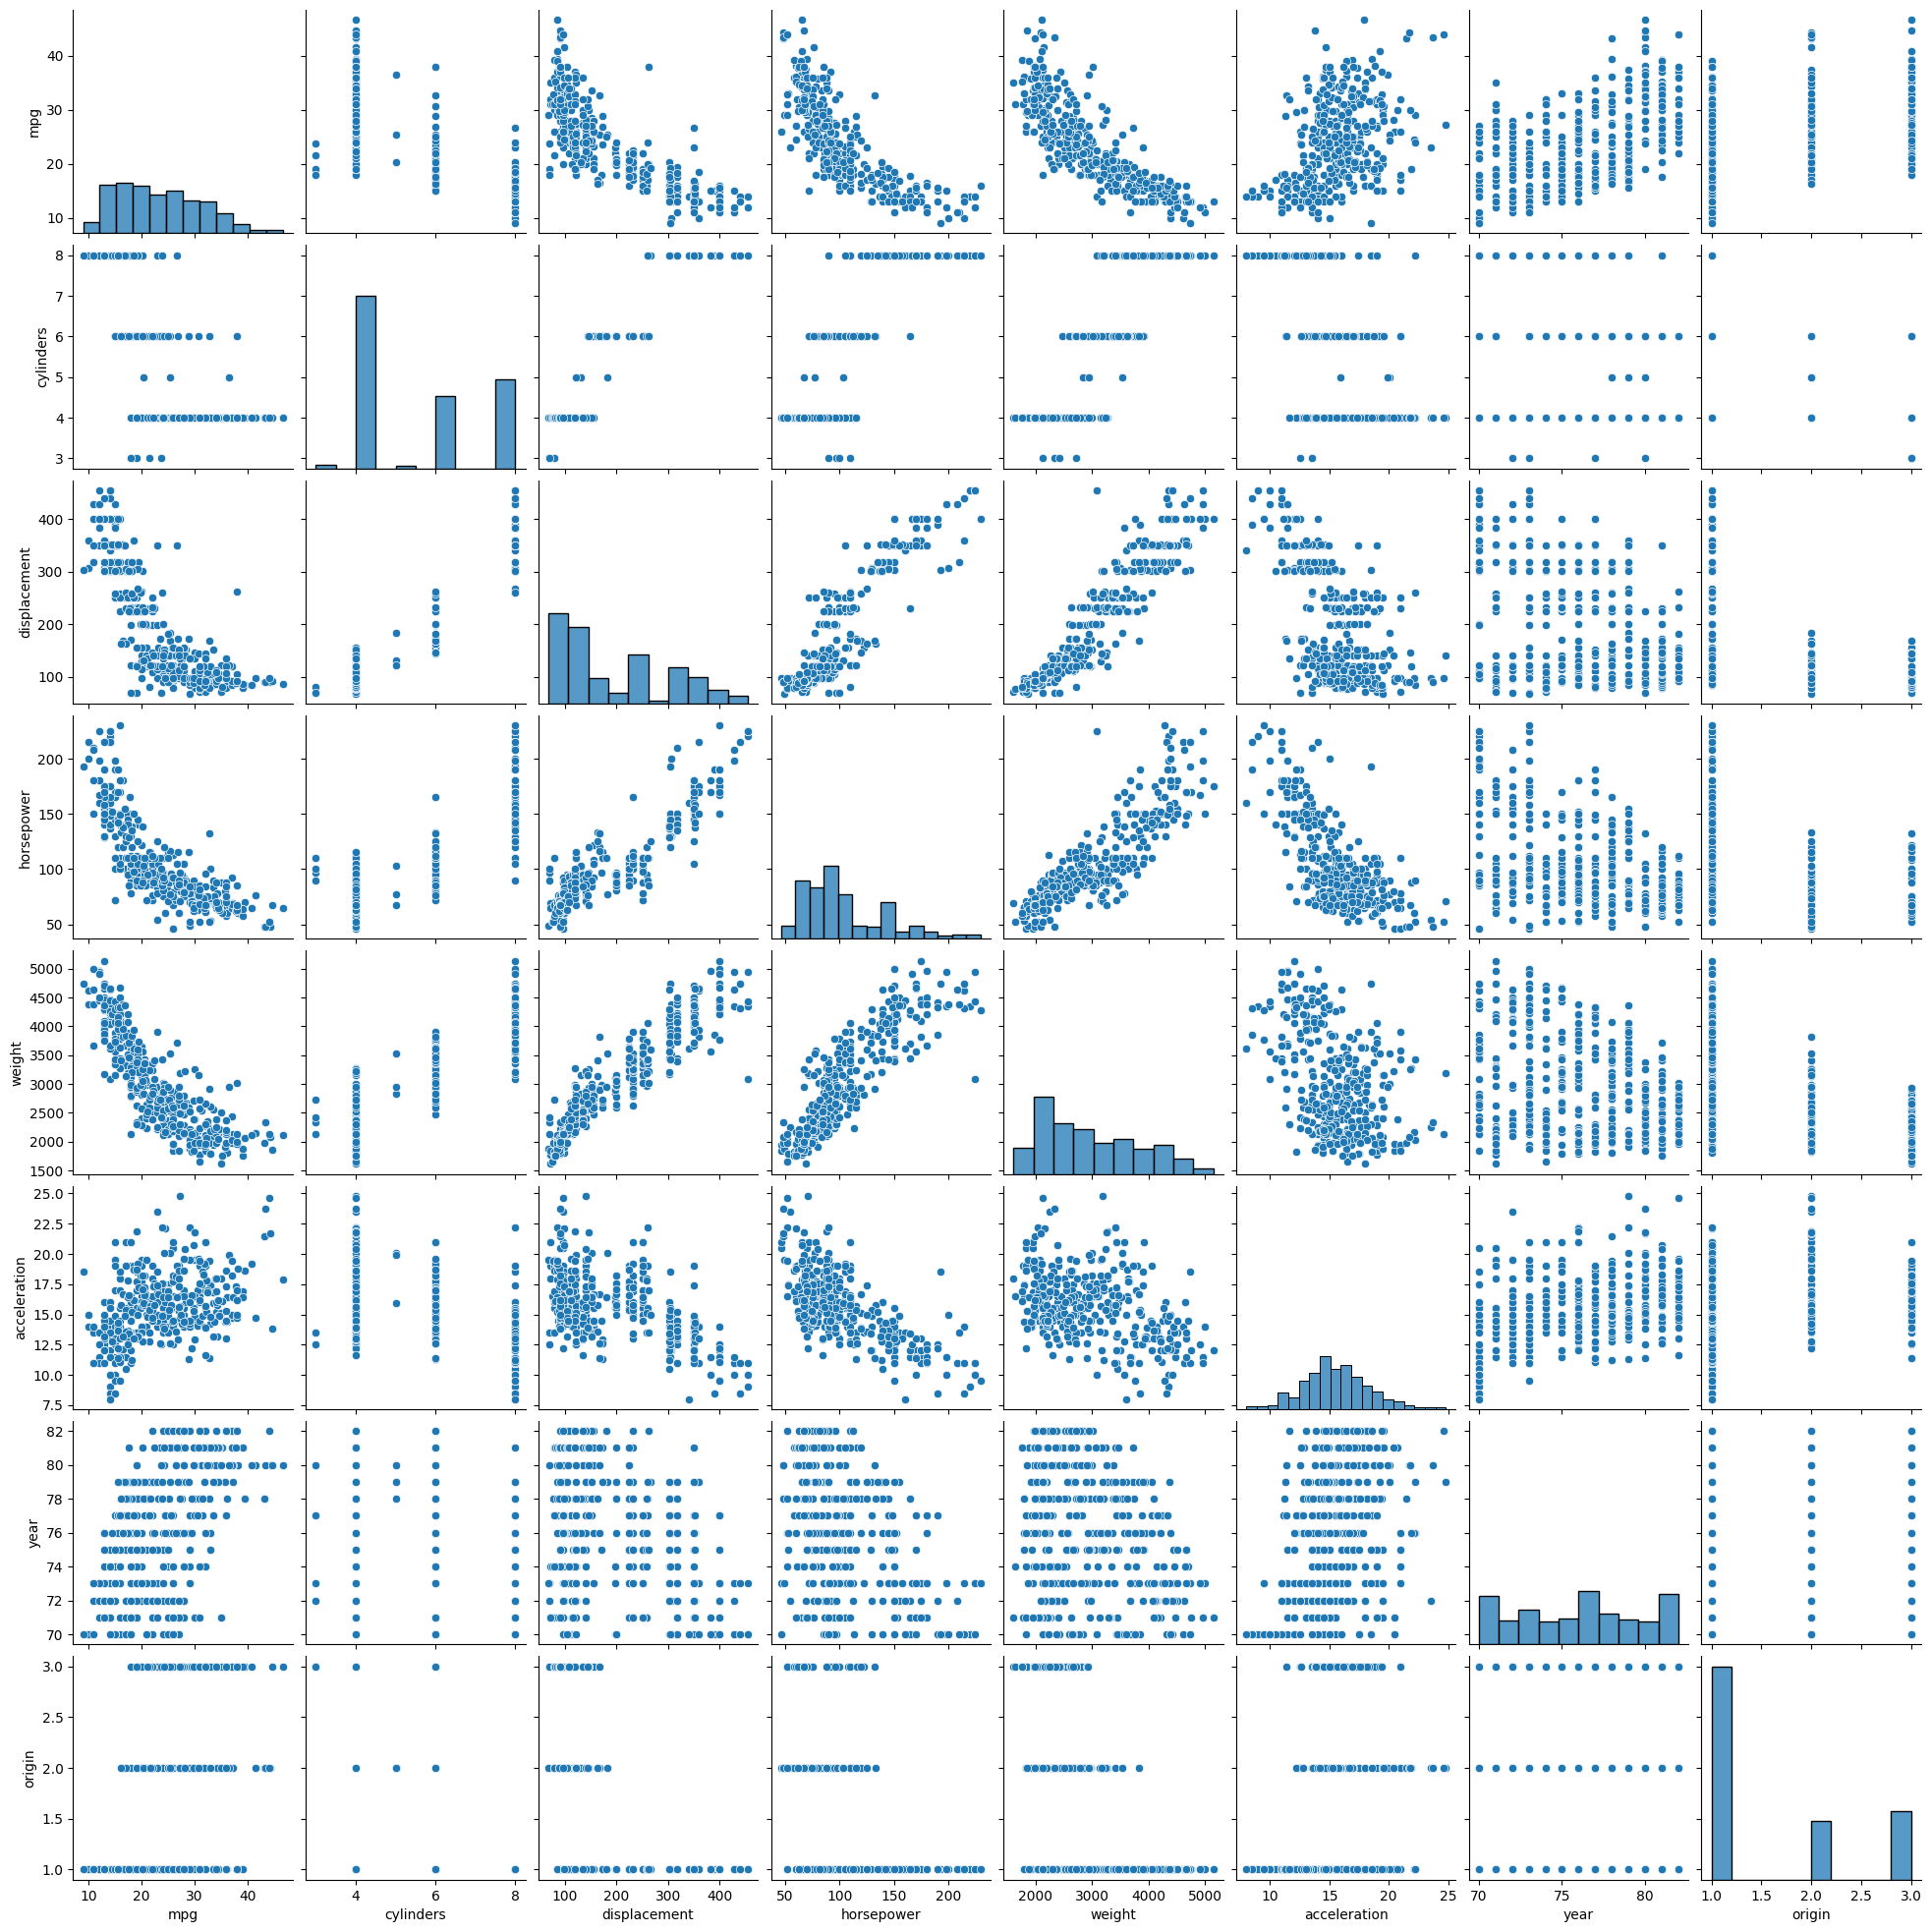

In [329]:
sns.pairplot(auto);

#### 9b)

In [331]:
# Correlation matrix
auto.iloc[:, :-1].corr()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
mpg,1.000000,-0.777618,-0.805127,-0.778427,-0.832244,0.423329,0.580541,0.565209
cylinders,-0.777618,1.000000,0.950823,0.842983,0.897527,-0.504683,-0.345647,-0.568932
displacement,-0.805127,0.950823,1.000000,0.897257,0.932994,-0.543800,-0.369855,-0.614535
horsepower,-0.778427,0.842983,0.897257,1.000000,0.864538,-0.689196,-0.416361,-0.455171
weight,-0.832244,0.897527,0.932994,0.864538,1.000000,-0.416839,-0.309120,-0.585005
acceleration,0.423329,-0.504683,-0.543800,-0.689196,-0.416839,1.000000,0.290316,0.212746
year,0.580541,-0.345647,-0.369855,-0.416361,-0.309120,0.290316,1.000000,0.181528
origin,0.565209,-0.568932,-0.614535,-0.455171,-0.585005,0.212746,0.181528,1.000000


#### 9c)

In [332]:
# Create response & predictors variables
X = auto.iloc[:, 1:-1]
columns = ['intercept'] + list(X.columns)
index = X.index
X = pd.DataFrame(
    data=np.column_stack((np.ones(X.shape[0]), X)),
    columns=columns,
    index=index
)
y = auto['mpg']

# Create & fit model
model = sm.OLS(y, X)
results = model.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    mpg   R-squared:                       0.821
Model:                            OLS   Adj. R-squared:                  0.818
Method:                 Least Squares   F-statistic:                     252.4
Date:                Wed, 27 May 2026   Prob (F-statistic):          2.04e-139
Time:                        14:36:36   Log-Likelihood:                -1023.5
No. Observations:                 392   AIC:                             2063.
Df Residuals:                     384   BIC:                             2095.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
intercept      -17.2184      4.644     -3.707      0.000     -26.350      -8.087
cylinders       -0.4934      0.323     -1.526      0.128      -1.129       0.142
displacement     0.0199      0.008      2.647      0.008       0.005       0.035
horsepower      -0.0170      0.014     -1.230      0.220      -0.044       0.010
weight          -0.0065      0.001     -9.929      0.000      -0.008      -0.005
acceleration     0.0806      0.099      0.815      0.415      -0.114       0.275
year             0.7508      0.051     14.729      0.000       0.651       0.851
origin           1.4261      0.278      5.127      0.000       0.879       1.973
==============================================================================
Omnibus:                       31.906   Durbin-Watson:                   1.309
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               53.100
Skew:                           0.529   Prob(JB):                     2.95e-12
Kurtosis:                       4.460   Cond. No.                     8.59e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 8.59e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

**i)** There is a relationship between predictors and the response statistically validaded by the F-test. We reject the null hypothesis of all coefficients are equal to 0.

**ii)** This is the list of statistically significant coefficients:
- intercept
- displacement
- weight
- year
- origin

**iii)** 'year' has a positive coefficient, this means that older cars, on average, will have a higher 'mpg' when compared to newer cars.
<br></br>



#### 9d)

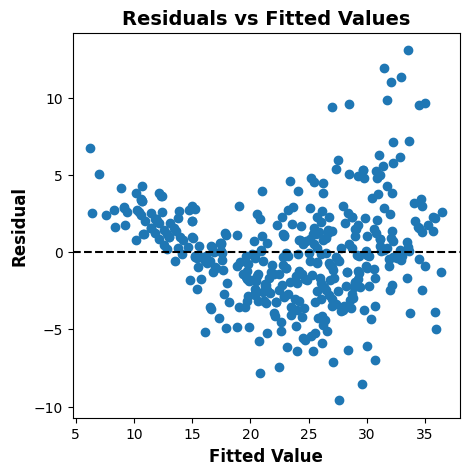

In [333]:
# Get residuals
y_pred = results.predict(X) # or results.fittedvalues
resid = y - y_pred # or results.resid

# Plot
plt.figure(figsize=(5,5))
plt.scatter(y_pred, resid)
plt.title('Residuals vs Fitted Values', **title_args)
plt.xlabel('Fitted Value', **label_args)
plt.ylabel('Residual', **label_args)
plt.axhline(0, c='k', ls='--');

The residuals versus fitted values plot reveals potential non-linearity in the data that the linear model is not capturing, along with signs of heteroskedasticity, indicated by increasing error variance as fitted values increase.
<br></br>

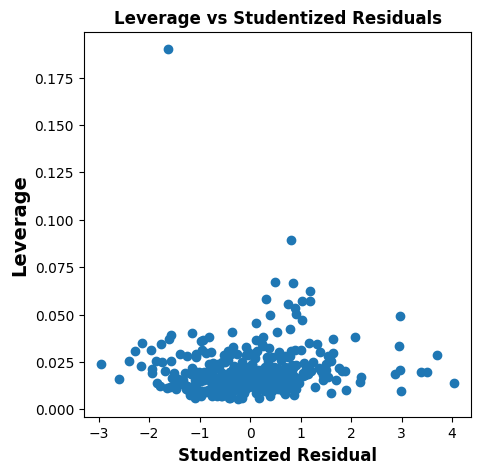

In [334]:
# Influence plot
infl = results.get_influence()
_, ax = subplots(figsize=(5,5))
ax.scatter(infl.resid_studentized_external, infl.hat_matrix_diag)
ax.set_title('Leverage vs Studentized Residuals', **label_args)
ax.set_xlabel('Studentized Residual', **label_args)
ax.set_ylabel('Leverage', **title_args);

The levarage vs studentized residuals plot reveals one observation with exceptionally high leverage and several others with notably large studentized residuals. This suggests we have both outliers and observations with high effect over the model.
<br></br>

#### 9e)

In [335]:
# Create a couple of interactions
weight_acc = X['weight'] * X['acceleration']
cylinders_hp = X['cylinders'] * X['horsepower']

# Add to a dataframe
index = X.index
columns = list(X.columns) + ['weight:acc', 'cylinders:hp']
X_new = np.column_stack((X, weight_acc, cylinders_hp))
X_new = pd.DataFrame(
    data=X_new,
    columns=columns,
    index=index
)

# Create & fit model
model_new = sm.OLS(y, X_new)
results_new = model_new.fit()
results_new.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    mpg   R-squared:                       0.863
Model:                            OLS   Adj. R-squared:                  0.859
Method:                 Least Squares   F-statistic:                     266.6
Date:                Wed, 27 May 2026   Prob (F-statistic):          1.09e-158
Time:                        14:36:37   Log-Likelihood:                -972.08
No. Observations:                 392   AIC:                             1964.
Df Residuals:                     382   BIC:                             2004.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
intercept        3.4989      8.175      0.428      0.669     -12.575      19.573
cylinders       -3.9041      0.559     -6.988      0.000      -5.003      -2.806
displacement    -0.0030      0.007     -0.431      0.666      -0.017       0.011
horsepower      -0.2940      0.035     -8.365      0.000      -0.363      -0.225
weight          -0.0019      0.002     -1.112      0.267      -0.005       0.001
acceleration     0.1807      0.294      0.615      0.539      -0.397       0.758
year             0.7470      0.045     16.506      0.000       0.658       0.836
origin           0.8668      0.251      3.451      0.001       0.373       1.361
weight:acc      -0.0001   9.85e-05     -1.255      0.210      -0.000       7e-05
cylinders:hp     0.0366      0.005      7.696      0.000       0.027       0.046
==============================================================================
Omnibus:                       40.379   Durbin-Watson:                   1.590
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               73.741
Skew:                           0.614   Prob(JB):                     9.71e-17
Kurtosis:                       4.734   Cond. No.                     2.60e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.6e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [336]:
# Compare both models
anova_lm(results, results_new)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,384.0,4252.212530,0.0,NaN,NaN,NaN
1,382.0,3271.482722,2.0,980.729808,57.258255,1.781421e-22


We see that both interaction terms has statistically significant coefficients at 5%. The F-statistic between the 2 models rejects the null hypothesis that the bigger model with interactions does not provide better fit than the simpler model.

#### 9f)

In [337]:
auto[['mpg', 'horsepower', 'acceleration', 'displacement']].corr()

,mpg,horsepower,acceleration,displacement
mpg,1.000000,-0.778427,0.423329,-0.805127
horsepower,-0.778427,1.000000,-0.689196,0.897257
acceleration,0.423329,-0.689196,1.000000,-0.543800
displacement,-0.805127,0.897257,-0.543800,1.000000


In [338]:
# Create transformations
horsepower2 = auto['horsepower']**2
horsepower_sqrt = np.sqrt(auto['horsepower'])
horsepower_log = np.log(auto['horsepower'])
acceleration_sqrt = np.sqrt(auto['acceleration'])
acceleration_log = np.log(auto['acceleration'])
displacement_sqrt = np.sqrt(auto['displacement'])
displacement_log = np.log(auto['displacement'])

# Check correlation
X_corr = np.column_stack((
    auto['mpg'],
    auto['horsepower'],
    horsepower2,
    horsepower_sqrt,
    horsepower_log,
    auto['acceleration'],
    acceleration_sqrt,
    acceleration_log,
    auto['displacement'],
    displacement_sqrt,
    displacement_log

))
columns = [
    'mpg',
    'horsepower',
    'horsepower2',
    'horsepower_sqrt',
    'horsepower_log',
    'acceleration',
    'acceleration_sqrt',
    'acceleration_log',
    'displacement',
    'displacement_sqrt',
    'displacement_log'
    
]
X_corr = pd.DataFrame(
    data=X_corr,
    columns=columns
)
X_corr.corr().iloc[:, 0]

mpg                  1.000000
horsepower          -0.778427
horsepower2         -0.712297
horsepower_sqrt     -0.802311
horsepower_log      -0.817517
acceleration         0.423329
acceleration_sqrt    0.430677
acceleration_log     0.435901
displacement        -0.805127
displacement_sqrt   -0.821331
displacement_log    -0.828453
Name: mpg, dtype: float64

Since correlation captures linear relationships, and we can see a slight increse in its coefficients when transforming the data, we can anticipate an improvement in a linear regression model when applying the same transformations to the data.
<br></br>

In [339]:
# Create a feature matrix
columns_transformed = ['horsepower', 'acceleration', 'displacement']
columns = [x for x in X_new.columns if x not in columns_transformed]
X_transformed = np.column_stack(
    (X_new[columns], horsepower_log, acceleration_log, displacement_log)
)
columns = columns + ['horsepower_log', 'acceleration_log', 'displacement_log']
index = X_new.index
X_transformed = pd.DataFrame(
    data=X_transformed,
    columns=columns,
    index=index
)

# Create & fit a model
model_transformed = sm.OLS(y, X_transformed)
results_transformed = model_transformed.fit()
results_transformed.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    mpg   R-squared:                       0.864
Model:                            OLS   Adj. R-squared:                  0.861
Method:                 Least Squares   F-statistic:                     269.0
Date:                Wed, 27 May 2026   Prob (F-statistic):          2.41e-159
Time:                        14:36:37   Log-Likelihood:                -970.53
No. Observations:                 392   AIC:                             1961.
Df Residuals:                     382   BIC:                             2001.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
intercept           71.6899     18.686      3.837      0.000      34.950     108.429
cylinders           -1.2924      0.375     -3.443      0.001      -2.030      -0.554
weight              -0.0027      0.002     -1.782      0.076      -0.006       0.000
year                 0.7472      0.045     16.721      0.000       0.659       0.835
origin               0.7119      0.266      2.675      0.008       0.189       1.235
weight:acc       -2.512e-05   9.21e-05     -0.273      0.785      -0.000       0.000
cylinders:hp         0.0134      0.002      6.748      0.000       0.009       0.017
horsepower_log     -16.8201      1.794     -9.377      0.000     -20.347     -13.293
acceleration_log    -3.6857      4.538     -0.812      0.417     -12.608       5.237
displacement_log    -2.1553      1.284     -1.679      0.094      -4.679       0.369
==============================================================================
Omnibus:                       31.260   Durbin-Watson:                   1.621
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               61.261
Skew:                           0.463   Prob(JB):                     4.98e-14
Kurtosis:                       4.701   Cond. No.                     6.12e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 6.12e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [340]:
answer_9f = f"""
<div class="custom-md">

When comparing the model with log-transformed features with 
the regular features, we see slight improvements in SSR (or RSS) 
and adjusted $R^2$.

The log-transformed model outputs an SSR of 
{results_transformed.ssr:.2f} and an adjusted $R^2$ of 
{results_transformed.rsquared_adj:.3f} in comparison to
{results_new.ssr:.2f} and {results_new.rsquared_adj:.3f}.

</div>
"""

display(Markdown(style + answer_9f))


<style>
.custom-md {
    font-size: 16px;
    line-height: 1.6;
    font-family: "Helvetica", "Arial", sans-serif;
}
</style>

<div class="custom-md">

When comparing the model with log-transformed features with 
the regular features, we see slight improvements in SSR (or RSS) 
and adjusted $R^2$.

The log-transformed model outputs an SSR of 
3245.70 and an adjusted $R^2$ of 
0.861 in comparison to
3271.48 and 0.859.

</div>


In [341]:
# Create a reduced linear model - only 'horsepower'
columns = ['intercept', 'horsepower']
model_reduced_regular = sm.OLS(y, X_new[columns])
results_reduced_regular = model_reduced_regular.fit()
results_reduced_regular.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    mpg   R-squared:                       0.606
Model:                            OLS   Adj. R-squared:                  0.605
Method:                 Least Squares   F-statistic:                     599.7
Date:                Wed, 27 May 2026   Prob (F-statistic):           7.03e-81
Time:                        14:36:37   Log-Likelihood:                -1178.7
No. Observations:                 392   AIC:                             2361.
Df Residuals:                     390   BIC:                             2369.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     39.9359      0.717     55.660      0.000      38.525      41.347
horsepower    -0.1578      0.006    -24.489      0.000      -0.171      -0.145
==============================================================================
Omnibus:                       16.432   Durbin-Watson:                   0.920
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               17.305
Skew:                           0.492   Prob(JB):                     0.000175
Kurtosis:                       3.299   Cond. No.                         322.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [342]:
# Create a reduced linear model - only 'horsepower_log'
columns = ['intercept', 'horsepower_log']
model_reduced_transformed = sm.OLS(y, X_transformed[columns])
results_reduced_transformed = model_reduced_transformed.fit()
results_reduced_transformed.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    mpg   R-squared:                       0.668
Model:                            OLS   Adj. R-squared:                  0.667
Method:                 Least Squares   F-statistic:                     785.9
Date:                Wed, 27 May 2026   Prob (F-statistic):           1.70e-95
Time:                        14:36:37   Log-Likelihood:                -1144.9
No. Observations:                 392   AIC:                             2294.
Df Residuals:                     390   BIC:                             2302.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
intercept        108.6997      3.050     35.644      0.000     102.704     114.695
horsepower_log   -18.5822      0.663    -28.034      0.000     -19.885     -17.279
==============================================================================
Omnibus:                       11.919   Durbin-Watson:                   1.031
Prob(Omnibus):                  0.003   Jarque-Bera (JB):               15.557
Skew:                           0.278   Prob(JB):                     0.000419
Kurtosis:                       3.803   Cond. No.                         64.6
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

When fitting a linear model using only 'horsepower' as a predictor, applying a log-transformation to the variable significantly improves model performance. It raises the adjusted $R^2$ from 0.605 to 0.667.

However, this improvement becomes less aparent when additional predictors are included in the model, as the effect of the transformation is masked by the presence of other features. This may suggest potential multicolinearity among the predictors.

---

### Question 10

#### 10a)

In [343]:
# Load data
carseats = pd.read_csv('data/Carseats.csv')
carseats.columns = [x.lower() for x in carseats.columns]
carseats.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   sales        400 non-null    float64
 1   compprice    400 non-null    int64  
 2   income       400 non-null    int64  
 3   advertising  400 non-null    int64  
 4   population   400 non-null    int64  
 5   price        400 non-null    int64  
 6   shelveloc    400 non-null    object 
 7   age          400 non-null    int64  
 8   education    400 non-null    int64  
 9   urban        400 non-null    object 
 10  us           400 non-null    object 
dtypes: float64(1), int64(7), object(3)
memory usage: 34.5+ KB


In [344]:
# Check first observations
carseats.head()

,sales,compprice,income,advertising,population,price,shelveloc,age,education,urban,us
0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes
1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes
2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes
3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes
4,4.15,141,64,3,340,128,Bad,38,13,Yes,No


In [345]:
# One-hot encode categorical variables
columns = ['price', 'urban', 'us']
X = pd.get_dummies(carseats[columns], drop_first=True, dtype='int')
X.insert(0, 'intercept', np.ones(X.shape[0]))
y = carseats['sales']

# Create & fit model
model = sm.OLS(y, X)
results = model.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  sales   R-squared:                       0.239
Model:                            OLS   Adj. R-squared:                  0.234
Method:                 Least Squares   F-statistic:                     41.52
Date:                Wed, 27 May 2026   Prob (F-statistic):           2.39e-23
Time:                        14:36:37   Log-Likelihood:                -927.66
No. Observations:                 400   AIC:                             1863.
Df Residuals:                     396   BIC:                             1879.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     13.0435      0.651     20.036      0.000      11.764      14.323
price         -0.0545      0.005    -10.389      0.000      -0.065      -0.044
urban_Yes     -0.0219      0.272     -0.081      0.936      -0.556       0.512
us_Yes         1.2006      0.259      4.635      0.000       0.691       1.710
==============================================================================
Omnibus:                        0.676   Durbin-Watson:                   1.912
Prob(Omnibus):                  0.713   Jarque-Bera (JB):                0.758
Skew:                           0.093   Prob(JB):                        0.684
Kurtosis:                       2.897   Cond. No.                         628.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

#### 10b)

Our linear model contains 'intercept', 'price', and dummy variables for 'urban' and 'us' locations to predict 'sales' of child car seats (in thousands). Therefore, all reported values should be interpreted in thousands units.

- The 'intercept' of ~13.04 means that when all other coefficients are equal to 0, expected 'sales' are 13,043 units.

- The 'price' coefficient is negative, which aligns with intuition: for every $100 increase in 'price', 'sales' are expected to decrease by about 5,450 units.

- The 'urban' dummy indicates that, on average, stores in an urban areas sell approximately 22 fewer units than their rural counterparts, holding all other features/variables constant.

- The 'us' dummy shows a positive effect: stores located in the US sell approximately 1,200 more units compared to those outside the US.

#### 10c)

$$
\widehat{sales}_i = 13.04 - 0.0545 \cdot price_i - 0.0219 \cdot urban_i + 1.20 \cdot us_i
$$

Where:
- urban_i = 1 if the store is in an urban area, 0 otherwise.
- us_i = 1 if the store is located in the US, 0 otherwise.

#### 10d)

We can reject the null hypothesis $H_0: \beta_j = 0$ for the 'intercept', 'price' and 'us'. The feature 'urban' is the only that fails to reject the null hypothesis.

#### 10e)

In [346]:
# Create new feature matrix
columns = ['price', 'us_Yes']
X_small = X[columns]
X_small.insert(0, 'intercept', np.ones(X_small.shape[0]))

# Create & fit model
model_small = sm.OLS(y, X_small)
results_small = model_small.fit()
results_small.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  sales   R-squared:                       0.239
Model:                            OLS   Adj. R-squared:                  0.235
Method:                 Least Squares   F-statistic:                     62.43
Date:                Wed, 27 May 2026   Prob (F-statistic):           2.66e-24
Time:                        14:36:37   Log-Likelihood:                -927.66
No. Observations:                 400   AIC:                             1861.
Df Residuals:                     397   BIC:                             1873.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     13.0308      0.631     20.652      0.000      11.790      14.271
price         -0.0545      0.005    -10.416      0.000      -0.065      -0.044
us_Yes         1.1996      0.258      4.641      0.000       0.692       1.708
==============================================================================
Omnibus:                        0.666   Durbin-Watson:                   1.912
Prob(Omnibus):                  0.717   Jarque-Bera (JB):                0.749
Skew:                           0.092   Prob(JB):                        0.688
Kurtosis:                       2.895   Cond. No.                         607.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

#### 10f)

In [347]:
# Compute RSE for the original model
n = X.shape[0]
k = X.shape[1]
pred = results.predict(X)
rss = sum((y - pred)**2)
rse = np.sqrt(rss / (n - k))

# Compute RSE for the small model
n = X_small.shape[0]
k = X_small.shape[1]
pred_small = results_small.predict(X_small)
rss_small = sum((y - pred_small)**2)
rse_small = np.sqrt(rss_small / (n - k))

# Compute PERCENTAGE ERROR
perc_error = rse / y.mean()
perc_error_small = rse_small / y.mean()

# Show results
print(
f"""
Original Model
--------------
rse:            {rse:.4f}
sales_mean:     {y.mean():.4f}
perc_error:     {perc_error:.2%}
rsquared_adj:   {results.rsquared_adj:.4f}

Small Model
-----------
rse:            {rse_small:.4f}
sales_mean:     {y.mean():.4f}
perc_error:     {perc_error_small:.2%}
rsquared_adj:   {results_small.rsquared_adj:.4f}
"""    
)


Original Model
--------------
rse:            2.4725
sales_mean:     7.4963
perc_error:     32.98%
rsquared_adj:   0.2335

Small Model
-----------
rse:            2.4694
sales_mean:     7.4963
perc_error:     32.94%
rsquared_adj:   0.2354



Both models have very similar results, indicating that the 'urban' does not contribute to the predictive power of the model. Overall, neither model provides a particularly strong fit to the data, as reflected by a low adjusted $R^2$ of roughly 0.23. This suggests that the model is only able to explain approximately 23% of the variation on 'sales'. Additionally, both models have a high percentage of error, with an average error rate around 33%.

In [348]:
# F-statistic comparing models
anova_lm(results_small, results)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,397.0,2420.874462,0.0,NaN,NaN,NaN
1,396.0,2420.834671,1.0,0.03979,0.006509,0.935739


The F-statistic supports the conclusion that the 'urban' variable/feature does not significantly improve the model. We fail to reject the null hypothesis that the simpler model is sufficient, indicating no statistical grounds for including 'urban'.

#### 10g)

| Feature    | 95% Confidence Interval   |
|------------|---------------------------|
| intercept  | [11.790, 14.271]          |
| price      | [-0.065, -0.044]          |
| us_Yes     | [0.692,  1.708]           |



#### 10h)

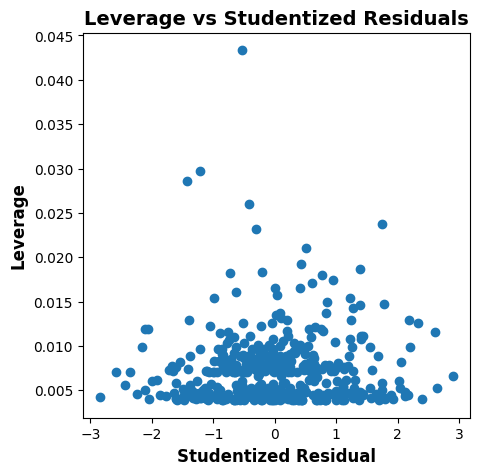

In [349]:
# Influence plot
infl = results_small.get_influence()
_, ax = subplots(figsize=(5,5))
ax.scatter(infl.resid_studentized_external, infl.hat_matrix_diag)
ax.set_title('Leverage vs Studentized Residuals', **title_args)
ax.set_xlabel('Studentized Residual', **label_args)
ax.set_ylabel('Leverage', **label_args);

In [350]:
# High Leverage
leverage_mean = k/n # infl.hat_matrix_diag.mean()
leverage_threshold = leverage_mean * 3
leverage_high_list = [x for x in infl.hat_matrix_diag if x > leverage_threshold]

# Outliers
outliers_list = [x for x in infl.resid_studentized_external if abs(x) >= 3]

# Print
print(
f"""
High Leverage: {len(leverage_high_list)}
Outliers:      {len(outliers_list)}
"""
)


High Leverage: 6
Outliers:      0



We identify 6 observations with high leverage, each exceeding 3 times the average leverage value. However, no outliers were detected based on studentized residuals, as none reached or exceeded an absolute value of 3.

---

### Question 11

#### 11a)

In [351]:
# Generate data
rng = np.random.default_rng(1)
x = rng.normal(size=100)
y = 2 * x + rng.normal(size=100)

In [352]:
# Creaet & fit model
model = sm.OLS(y, x)
results = model.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                      y   R-squared (uncentered):                   0.743
Model:                            OLS   Adj. R-squared (uncentered):              0.740
Method:                 Least Squares   F-statistic:                              285.6
Date:                Wed, 27 May 2026   Prob (F-statistic):                    6.23e-31
Time:                        14:36:37   Log-Likelihood:                         -141.35
No. Observations:                 100   AIC:                                      284.7
Df Residuals:                      99   BIC:                                      287.3
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1             1.9762      0.117     16.898      0.000       1.744       2.208
==============================================================================
Omnibus:                        1.376   Durbin-Watson:                   2.184
Prob(Omnibus):                  0.503   Jarque-Bera (JB):                0.847
Skew:                           0.121   Prob(JB):                        0.655
Kurtosis:                       3.381   Cond. No.                         1.00
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

When performing a linear regression without an intercept, we see that $\hat \beta$ is estimated as 1.9762, which is very close to the real value of 2. We only know the true value because we've generated the real data ourselves. The standard error of this estimate is 0.117, which provides a 95% confidence interval (CI) of [1.744, 2.208].

Additionally, the t-statistic value of 16.898 is very high, causing the p-value to be equal to 0. This means we reject the null hypothesis of $H_0: \beta = 0$, therefore the coefficient is statiscally significant and there is a relationship with the endogenous variable ('y').

#### 11b)

In [353]:
# Create & fit a model
model2 = sm.OLS(x, y)
results2 = model2.fit()
results2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                      y   R-squared (uncentered):                   0.743
Model:                            OLS   Adj. R-squared (uncentered):              0.740
Method:                 Least Squares   F-statistic:                              285.6
Date:                Wed, 27 May 2026   Prob (F-statistic):                    6.23e-31
Time:                        14:36:37   Log-Likelihood:                         -58.349
No. Observations:                 100   AIC:                                      118.7
Df Residuals:                      99   BIC:                                      121.3
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1             0.3757      0.022     16.898      0.000       0.332       0.420
==============================================================================
Omnibus:                       13.156   Durbin-Watson:                   2.034
Prob(Omnibus):                  0.001   Jarque-Bera (JB):               22.596
Skew:                          -0.528   Prob(JB):                     1.24e-05
Kurtosis:                       5.075   Cond. No.                         1.00
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

When performing a linear regression without an intercept of 'x' onto 'y', we get a $\hat{\beta}$ coefficient of 0.3757. The standard error of the estimate is 0.022, which results in a 95% confidence interval (CI) of [0.332, 0.420].

Just as in the previous linear regression, the coefficient gets a t-statistic value of 16.898 and a p-value of 0. This means that the coefficient is statistically sifnificant and there is a relationship with the endogenous variable ('x').

#### 11c)

The results from both regression models appear relatively similar based on the generated data. They output identical t-statistics and adjusted $R^2$ values. However, there is a discrepancey in the estimated coefficient $\beta_1$ when regression 'x' onto 'y'. This estimate deviates substantially from the true value and the true value lies outside the 95% CI of the estimate.

When regressing 'y' onto 'x', the estimated coefficient is much closer to the true value and falls within its confidence interval. This shows that the models are not reciprocal, they do not provide the inverse estimated coefficient of each other, and the coefficient from regressing 'y' onto 'x' is more reasonable.

#### 11d)

![solution](images/chapter3/solution_11d.png)

obs: the left term in the denominator should be $(\sum_{i=1}^n x_i y_i)^2$ and not $(\sum_{i=1}^n x_i^2 y_i^2)$

#### 11e)

The t-statistic will be the same for the regression of 'y' onto 'x' as for the regression of 'x' onto 'y' because part d) shows us that the t-statistic is a symmetric function of 'x' and 'y'.

#### 11f)

In [354]:
# Create feature matrices
X_ = np.column_stack((np.ones(len(x)), x))
Y_ = np.column_stack((np.ones(len(y)), y))

# Create & fit 1st model
model1 = sm.OLS(y, X_)
results1 = model1.fit()
results1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.741
Model:                            OLS   Adj. R-squared:                  0.738
Method:                 Least Squares   F-statistic:                     280.0
Date:                Wed, 27 May 2026   Prob (F-statistic):           1.74e-30
Time:                        14:36:37   Log-Likelihood:                -141.06
No. Observations:                 100   AIC:                             286.1
Df Residuals:                      98   BIC:                             291.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0760      0.101     -0.756      0.451      -0.276       0.124
x1             1.9686      0.118     16.734      0.000       1.735       2.202
==============================================================================
Omnibus:                        1.277   Durbin-Watson:                   2.198
Prob(Omnibus):                  0.528   Jarque-Bera (JB):                0.759
Skew:                           0.114   Prob(JB):                        0.684
Kurtosis:                       3.361   Cond. No.                         1.20
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [355]:
# Create & fit 2nd model
model2 = sm.OLS(x, Y_)
results2 = model2.fit()
results2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.741
Model:                            OLS   Adj. R-squared:                  0.738
Method:                 Least Squares   F-statistic:                     280.0
Date:                Wed, 27 May 2026   Prob (F-statistic):           1.74e-30
Time:                        14:36:37   Log-Likelihood:                -58.325
No. Observations:                 100   AIC:                             120.6
Df Residuals:                      98   BIC:                             125.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0095      0.044      0.216      0.829      -0.078       0.097
x1             0.3763      0.022     16.734      0.000       0.332       0.421
==============================================================================
Omnibus:                       13.123   Durbin-Watson:                   2.035
Prob(Omnibus):                  0.001   Jarque-Bera (JB):               22.501
Skew:                          -0.528   Prob(JB):                     1.30e-05
Kurtosis:                       5.070   Cond. No.                         1.98
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

We see the same t-statistic of 16.734 for $\beta_1$ in both models.

---

### Question 12

#### 12a)

$$
\hat{\beta} = \frac{(\sum_{i=1}^n x_i y_i)}{(\sum_{i'=1}^n x_i'^2)}
$$

Since the numerator will remain the same for a linear regression of 'y' onto 'x' as for 'x' onto 'y', the estimated coefficient $\beta$ will be the same when $(\sum_{i'=1}^n x_i'^2)$ is equal to $(\sum_{i'=1}^n y_i'^2)$.

#### 12b)

In [356]:
# Generate data
rng = np.random.default_rng(1)
x = rng.normal(size=100)
y = 4 * x + rng.normal(size=100)

# Create & fit the models
model1 = sm.OLS(y, x)
results1 = model1.fit()
model2 = sm.OLS(x, y)
results2 = model2.fit()

# Show summaries
print(summarize(results1), '\n')
print(summarize(results2))

      coef  std err     t  P>|t|
x1  3.9762    0.117  34.0    0.0 

      coef  std err     t  P>|t|
x1  0.2317    0.007  34.0    0.0


#### 12c)

In [357]:
# Generate feature/predictor
n = 100
x = np.arange(n)

# Center & standardize
x = x - np.mean(x)
x = x / np.std(x)

# Generate response based on predictor
y = x + rng.normal(size=n)
y = y - np.mean(y)
y = y / np.std(y)

# Create & fit regressions
model1 = sm.OLS(y, x)
results1 = model1.fit()
model2 = sm.OLS(x, y)
results2 = model2.fit()

# Show summaries
print(summarize(results1), '\n')
print(summarize(results2))

      coef  std err      t  P>|t|
x1  0.7508    0.066  11.31    0.0 

      coef  std err      t  P>|t|
x1  0.7508    0.066  11.31    0.0


This example shows that when both 'x' and 'y' are centered around zero and have the same standardized variance, the estimated regression coefficient for 'x' onto 'y' will be the same to that of 'y' onto 'x'.

---

### Question 13

#### 13a)

In [358]:
# Generate data
rng = np.random.default_rng(1)
x = rng.normal(size=100)

#### 13b)

In [359]:
# Generate 'eps'
eps = rng.normal(loc=0, scale=0.25, size=100)

#### 13c)

In [360]:
# Create 'y'
y = -1 + (0.5 * x) + eps

#### 13d)

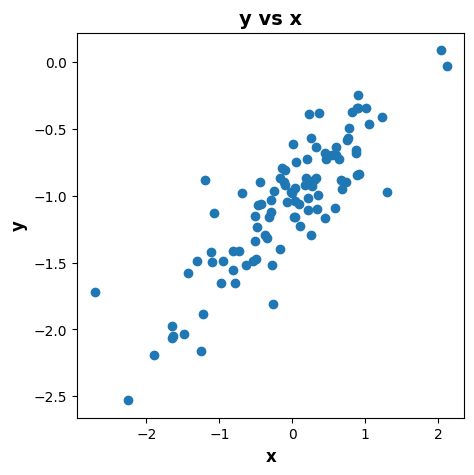

In [361]:
plt.figure(figsize=(5,5))
plt.scatter(x, y)
plt.title('y vs x', **title_args)
plt.xlabel('x', **label_args)
plt.ylabel('y', **label_args);

#### 13e)

In [362]:
# Add intercept to 'X'
X = np.column_stack((np.ones(len(x)), x))
X = pd.DataFrame(X, columns=['intercept', 'x'])

# Create & fit model
model = sm.OLS(y, X)
results = model.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.741
Model:                            OLS   Adj. R-squared:                  0.738
Method:                 Least Squares   F-statistic:                     280.0
Date:                Wed, 27 May 2026   Prob (F-statistic):           1.74e-30
Time:                        14:36:37   Log-Likelihood:                -2.4306
No. Observations:                 100   AIC:                             8.861
Df Residuals:                      98   BIC:                             14.07
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     -1.0190      0.025    -40.537      0.000      -1.069      -0.969
x              0.4921      0.029     16.734      0.000       0.434       0.551
==============================================================================
Omnibus:                        1.277   Durbin-Watson:                   2.198
Prob(Omnibus):                  0.528   Jarque-Bera (JB):                0.759
Skew:                           0.114   Prob(JB):                        0.684
Kurtosis:                       3.361   Cond. No.                         1.20
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Our model estimates coefficients very close to their true values: $\hat{\beta_0} = -1.019$ and $\hat{\beta_1} = 0.4921$, while the actual parameters are $\beta_0 = -1$ and $\beta_1 = 0.5$. Despite the strong alignment between the estimated and true coefficients, the model yields an adjusted $R^2$ of 0.738, indicating that it explains approximately 73.8% of the variance of 'y'. This less-than-perfec fit is primarily due to the random noise term 'eps' that was introduced in the data.


#### 13f)

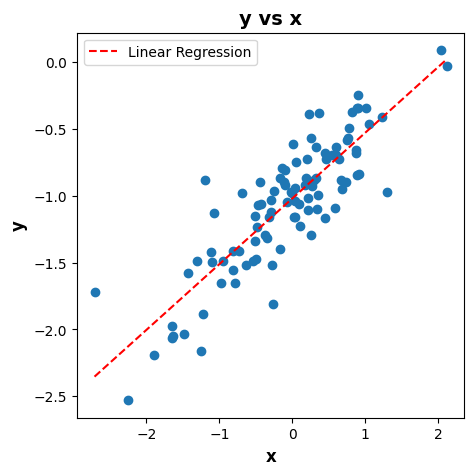

In [363]:
# Predict
xmin = x.min()
xmax = x.max()
xrange = np.linspace(xmin, xmax, 200)
Xrange = np.column_stack((np.ones(len(xrange)), xrange))
preds = results.predict(Xrange)

# Plot
plt.figure(figsize=(5,5))
plt.scatter(x, y)
plt.plot(
    xrange, 
    preds, 
    label='Linear Regression', 
    c='red', 
    ls='--'
)
plt.title('y vs x', **title_args)
plt.xlabel('x', **label_args)
plt.ylabel('y', **label_args)
plt.legend();


#### 13g)

In [364]:
# Create new feature dataset
Xnew = X.copy()
x2 = x**2
Xnew.insert(2, 'x2', x2)

# Create & fit new model
model_new = sm.OLS(y, Xnew)
results_new = model_new.fit()
results_new.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.741
Model:                            OLS   Adj. R-squared:                  0.735
Method:                 Least Squares   F-statistic:                     138.6
Date:                Wed, 27 May 2026   Prob (F-statistic):           3.66e-29
Time:                        14:36:37   Log-Likelihood:                -2.4293
No. Observations:                 100   AIC:                             10.86
Df Residuals:                      97   BIC:                             18.67
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     -1.0182      0.030    -34.186      0.000      -1.077      -0.959
x              0.4916      0.032     15.562      0.000       0.429       0.554
x2            -0.0012      0.023     -0.052      0.959      -0.046       0.044
==============================================================================
Omnibus:                        1.338   Durbin-Watson:                   2.197
Prob(Omnibus):                  0.512   Jarque-Bera (JB):                0.814
Skew:                           0.119   Prob(JB):                        0.666
Kurtosis:                       3.372   Cond. No.                         2.23
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [365]:
# F-statistic
anova_lm(results, results_new)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,98.0,6.146642,0.0,NaN,NaN,NaN
1,97.0,6.146471,1.0,0.00017,0.002688,0.958757


There is no evidence that incorporating $x^2$ feature improves the model. In fact, we have solid justification for excluding it. First, we fail to reject the null $H_0 : \hat{\beta_2} = 0$, indicating that the quadratic term is not statistically significant. Second, the F-test comparing the 2 models does not reject the null hypothesis that the simpler model (without $x^2$) is better.


#### 13h)

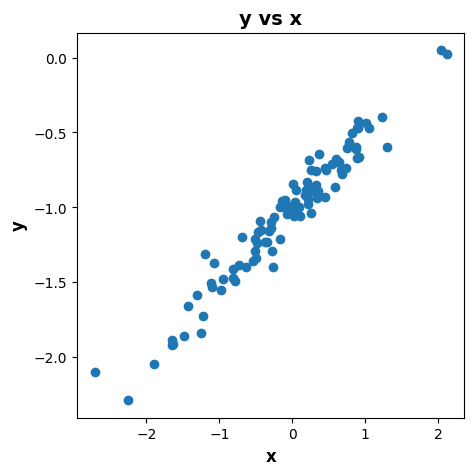

In [366]:
# Generate data
rng = np.random.default_rng(1)
x = rng.normal(size=100)
eps = rng.normal(loc=0, scale=0.1, size=100)
y = -1 + (0.5 * x) + eps

# Plot data
plt.figure(figsize=(5,5))
plt.scatter(x, y)
plt.title('y vs x', **title_args)
plt.xlabel('x', **label_args)
plt.ylabel('y', **label_args);

In [367]:
# Create feature matrix - add intercept
X = np.column_stack((np.ones(len(x)), x))

# Create & fit model
model1 = sm.OLS(y, X)
results1 = model1.fit()
results1.summary() 

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.948
Model:                            OLS   Adj. R-squared:                  0.947
Method:                 Least Squares   F-statistic:                     1784.
Date:                Wed, 27 May 2026   Prob (F-statistic):           1.08e-64
Time:                        14:36:37   Log-Likelihood:                 89.198
No. Observations:                 100   AIC:                            -174.4
Df Residuals:                      98   BIC:                            -169.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.0076      0.010   -100.209      0.000      -1.028      -0.988
x1             0.4969      0.012     42.236      0.000       0.474       0.520
==============================================================================
Omnibus:                        1.277   Durbin-Watson:                   2.198
Prob(Omnibus):                  0.528   Jarque-Bera (JB):                0.759
Skew:                           0.114   Prob(JB):                        0.684
Kurtosis:                       3.361   Cond. No.                         1.20
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

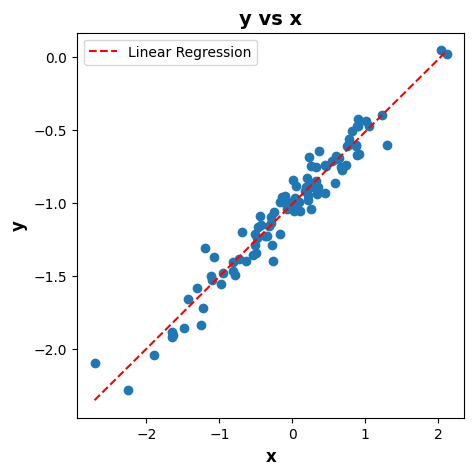

In [368]:
# Predict
xmin = x.min()
xmax = x.max()
xrange = np.linspace(xmin, xmax, 200)
Xrange = np.column_stack((np.ones(len(xrange)), xrange))
preds = results1.predict(Xrange)

# Plot
plt.figure(figsize=(5,5))
plt.scatter(x, y)
plt.plot(xrange, preds, label='Linear Regression', c='red', ls='--')
plt.title('y vs x', **title_args)
plt.xlabel('x', **label_args)
plt.ylabel('y', **label_args)
plt.legend();

The scatterplot shows reduced dispersion in the data, which contributes to a stronger linear relationship and a better model fit. As a results, the linear regression outputs a high adjusted $R^2$ of 0.947, indicating that the model explains approximately 94.7% of the true values, differing only at the third decimal place. Additionally, the standard errors are small, leading to a narrow 95% confidence intervals and greater precision in the paramter estimate.


#### 13i)

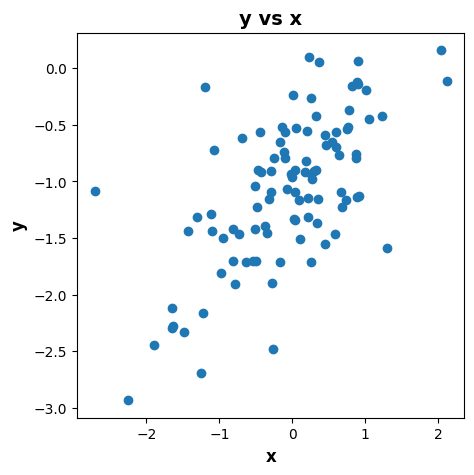

In [369]:
# Generate data
rng = np.random.default_rng(1)
x = rng.normal(size=100)
eps = rng.normal(loc=0, scale=0.5, size=100)
y = -1 + (0.5 * x) + eps

# Plot data
plt.figure(figsize=(5,5))
plt.scatter(x, y)
plt.title('y vs x', **title_args)
plt.xlabel('x', **label_args)
plt.ylabel('y', **label_args);

In [370]:
# Create feature matrix - add intercept
X = np.column_stack((np.ones(len(x)), x))

# Create & fit model
model2 = sm.OLS(y, X)
results2 = model2.fit()
results2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.409
Model:                            OLS   Adj. R-squared:                  0.403
Method:                 Least Squares   F-statistic:                     67.79
Date:                Wed, 27 May 2026   Prob (F-statistic):           8.04e-13
Time:                        14:36:37   Log-Likelihood:                -71.745
No. Observations:                 100   AIC:                             147.5
Df Residuals:                      98   BIC:                             152.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.0380      0.050    -20.647      0.000      -1.138      -0.938
x1             0.4843      0.059      8.233      0.000       0.368       0.601
==============================================================================
Omnibus:                        1.277   Durbin-Watson:                   2.198
Prob(Omnibus):                  0.528   Jarque-Bera (JB):                0.759
Skew:                           0.114   Prob(JB):                        0.684
Kurtosis:                       3.361   Cond. No.                         1.20
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

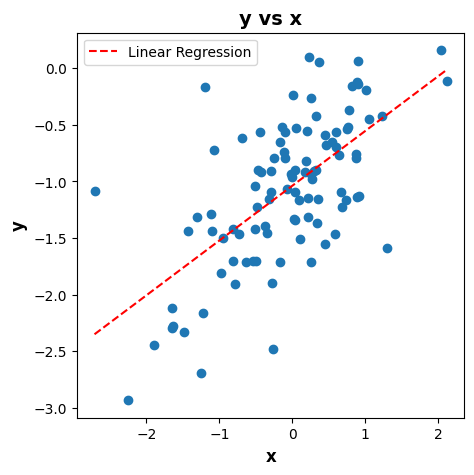

In [371]:
# Predict
xmin = x.min()
xmax = x.max()
xrange = np.linspace(xmin, xmax, 200)
Xrange = np.column_stack((np.ones(len(xrange)), xrange))
preds = results2.predict(Xrange)

# Plot
plt.figure(figsize=(5,5))
plt.scatter(x, y)
plt.plot(xrange, preds, label='Linear Regression', c='red', ls='--')
plt.title('y vs x', **title_args)
plt.xlabel('x', **label_args)
plt.ylabel('y', **label_args)
plt.legend();

With more dispersion in the data, the model's ability to fit the data deteriorates. This is reflected in a substantially lower adjusted $R^2$ of 0.403, indicating that the model explains only about 40.3% of the variation in 'y'. While the estimated coefficients remain close to the true values, they deviate more than in the previous scenario. Moreover, the 95% confidence intervals are considerably wider, indicating increased uncertainty around the parameter estimates and reducing the reliability of the model's predictions.


#### 13j)

| Model | $\hat{\beta_0}$ [95% CI] | $\hat{\beta_1}$ [95% CI] |
|-------|----------------------|--------------------------|
| Original | [-1.069, -0.969] | [0.434, 0.551] |
| Less Noise | [-1.028, -0.988] | [0.474, 0.520] |
| More Noise | [-1.138, -0.938] | [0.368, 0.601] |

As discussed earlier, the level of noise in the data directly impacts the width of the confidence intervals for the estimated parameters. When the noise is reduced, the confidence intervals become narrower, offering greater precision and confidence in the estimated values. Conversely, higher noise levels result in wider confidence intervals, reducing the reliability of both the model estimates and its predictions.

---

### Question 14

#### 14a)

In [372]:
# Generate data
rng = np.random.default_rng(10)
x1 = rng.uniform(0, 1, size=100)
x2 = 0.5 * x1 + rng.normal(size=100) / 10
y = 2 + 2 * x1 + 0.3 * x2 + rng.normal(size=100)

$$
y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \epsilon
$$


where $\beta_0 = 2$, $\beta_1 = 2$, and $\beta_2 = 0.3$.

#### 14b)

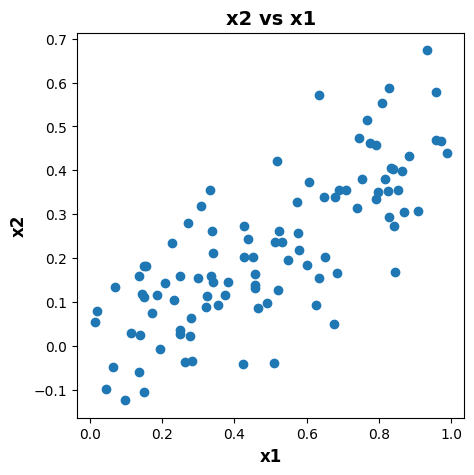

In [373]:
# Plot the features
plt.figure(figsize=(5,5))
plt.scatter(x1, x2)
plt.title('x2 vs x1', **title_args)
plt.xlabel('x1', **label_args)
plt.ylabel('x2', **label_args);

In [374]:
np.corrcoef(x1, x2)

array([[1.       , 0.7723245],
       [0.7723245, 1.       ]])

Since we have generated the data, we know that x2 is a positive linear transformation of x1. In theory, the correlation coefficient, which measures the linear association between the variables, should be exactly +1

However, the observed correlation coefficient is approximately 0.77. This deviation from +1 is due to the random noise we introduced into the data.

#### 14c)

In [375]:
# Create a feature matrix
X = np.column_stack((np.ones(len(x1)), x1, x2))
X = pd.DataFrame(X, columns=['intercept', 'x1', 'x2'])

# Create & fit a linear regression model
model = sm.OLS(y, X)
results = model.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.291
Model:                            OLS   Adj. R-squared:                  0.276
Method:                 Least Squares   F-statistic:                     19.89
Date:                Wed, 27 May 2026   Prob (F-statistic):           5.76e-08
Time:                        14:36:38   Log-Likelihood:                -130.62
No. Observations:                 100   AIC:                             267.2
Df Residuals:                      97   BIC:                             275.1
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      1.9579      0.190     10.319      0.000       1.581       2.334
x1             1.6154      0.527      3.065      0.003       0.569       2.661
x2             0.9428      0.831      1.134      0.259      -0.707       2.592
==============================================================================
Omnibus:                        0.051   Durbin-Watson:                   1.964
Prob(Omnibus):                  0.975   Jarque-Bera (JB):                0.041
Skew:                          -0.036   Prob(JB):                        0.979
Kurtosis:                       2.931   Cond. No.                         11.9
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Our linear regression model explains only 0.276, or 27.6% of y's variation, accordingly to the adjusted $R^2$. This result is far from an accurate model.

The model predicts $\beta_0 = 1.96$, $beta_1 = 1.61$, and $beta_2 = 0.94$. The coefficient estimates for features x1 and x2 are not really close to the true values of 2 and 0.3. Additionally, we cannot reject the null hypothesis $H_0 : \beta_2 = 0$, which means that the coefficient is not statistically significant.


#### 14d)

In [376]:
# Create a feature matrix
X_new = X[['intercept', 'x1']].copy()

# Create & fit the model
model_new = sm.OLS(y, X_new)
results_new = model_new.fit()
results_new.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.281
Model:                            OLS   Adj. R-squared:                  0.274
Method:                 Least Squares   F-statistic:                     38.39
Date:                Wed, 27 May 2026   Prob (F-statistic):           1.37e-08
Time:                        14:36:38   Log-Likelihood:                -131.28
No. Observations:                 100   AIC:                             266.6
Df Residuals:                      98   BIC:                             271.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      1.9371      0.189     10.242      0.000       1.562       2.312
x1             2.0771      0.335      6.196      0.000       1.412       2.742
==============================================================================
Omnibus:                        0.204   Durbin-Watson:                   1.931
Prob(Omnibus):                  0.903   Jarque-Bera (JB):                0.042
Skew:                          -0.046   Prob(JB):                        0.979
Kurtosis:                       3.038   Cond. No.                         4.65
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

When fitting a linear model of 'y' on 'x1' alone, the estimated \$\beta\_1\$ coefficient is much closer to its true value. This results from the removal of the root of collinearity in the model ('x2'). Without another correlated predictor competing to explain the variation in 'y', \$\beta\_1\$ is estimated with greater precision and a smaller standard error. Moreover, we still reject the null hypothesis \$H\_0 : \beta\_1 = 0\$, indicating that \$\beta\_1\$ is statistically significant.

It's worth noting that the adjusted $R^2$ experienced only a slight decrease, dropping from 0.276 to 0.274.


#### 14e)

In [377]:
# Create a dataframe matrix
X2 = np.column_stack((np.ones(len(x2)), x2))

# Create & fit a linear regression
model = sm.OLS(y, X2)
results = model.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.222
Model:                            OLS   Adj. R-squared:                  0.214
Method:                 Least Squares   F-statistic:                     27.99
Date:                Wed, 27 May 2026   Prob (F-statistic):           7.43e-07
Time:                        14:36:38   Log-Likelihood:                -135.24
No. Observations:                 100   AIC:                             274.5
Df Residuals:                      98   BIC:                             279.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.3239      0.154     15.124      0.000       2.019       2.629
x1             2.9103      0.550      5.291      0.000       1.819       4.002
==============================================================================
Omnibus:                        0.191   Durbin-Watson:                   1.943
Prob(Omnibus):                  0.909   Jarque-Bera (JB):                0.373
Skew:                          -0.034   Prob(JB):                        0.830
Kurtosis:                       2.709   Cond. No.                         6.11
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

When fitting only 'y' on 'x2' we get a great increase in the estimated coefficient, and it now stands much higher than the real value. Moreover, we now reject the null hypothesis $H_0 : \beta_1 = 0$, indicating that the coefficient is statistically significant in this simplified model.

#### 14f)

At first glance, the result in e) appears to contradict that of c), since we reject the null hypothesis for the coefficient in e) but not in c). However, this is not truly a contradiction once we consider collinearity issues. When in a presence of highly correlated features, the coefficients get inflated standard errors and weakens statistical significance.


#### 14g)

##### <u>Linear Regression #1</u>

$$
y = \beta_0 + \beta_1x_1 + \beta_2x_2 
$$

In [378]:
# Add new observation
x1 = np.concatenate([x1, [0.1]])
x2 = np.concatenate([x2, [0.8]])
y = np.concatenate([y, [6]])

# Create feature matrix
X = np.column_stack((np.ones(len(x1)), x1, x2))

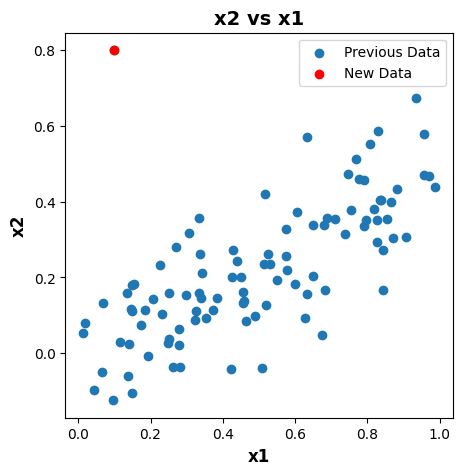

In [379]:
# Plot
plt.figure(figsize=(5,5))
plt.scatter(x1, x2, label='Previous Data')
plt.scatter(x1[-1], x2[-1], c='red', label='New Data')
plt.title('x2 vs x1', **title_args)
plt.xlabel('x1', **label_args)
plt.ylabel('x2', **label_args)
plt.legend();

In [380]:
# Print some information
print(
f"""
'y' info
--------
mean data:  {y[:-1].mean():.2f}
new obs:    {y[-1]}

'x1' info
---------
mean data:  {x1[:-1].mean():.2f}
new obs:    {x1[-1]}

'x2' info
---------
mean data:  {x2[:-1].mean():.2f}
new obs:    {x2[-1]}
"""
)


'y' info
--------
mean data:  2.96
new obs:    6.0

'x1' info
---------
mean data:  0.49
new obs:    0.1

'x2' info
---------
mean data:  0.22
new obs:    0.8



Based on the scatterplot and center of data stats, the new observation is likely to influence the model's fit significanlty. All of its values deviate substantially from the data's center. Its 'y' value is roughly 2x the mean, 'x1' is approximately 1/5 of the mean, and 'x2' is nearly 4x the mean.

In [381]:
# Create & fit a model
model = sm.OLS(y, X)
results = model.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.292
Model:                            OLS   Adj. R-squared:                  0.277
Method:                 Least Squares   F-statistic:                     20.17
Date:                Wed, 27 May 2026   Prob (F-statistic):           4.60e-08
Time:                        14:36:38   Log-Likelihood:                -135.30
No. Observations:                 101   AIC:                             276.6
Df Residuals:                      98   BIC:                             284.5
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.0618      0.192     10.720      0.000       1.680       2.443
x1             0.8575      0.466      1.838      0.069      -0.068       1.783
x2             2.2663      0.705      3.216      0.002       0.868       3.665
==============================================================================
Omnibus:                        0.139   Durbin-Watson:                   1.894
Prob(Omnibus):                  0.933   Jarque-Bera (JB):                0.320
Skew:                           0.013   Prob(JB):                        0.852
Kurtosis:                       2.725   Cond. No.                         9.68
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

The new observation has greatly affected the model when compared to the previous model without it. $\beta_1$ has a much lower coefficient of 0.49, and it is no longer statistical significant. Meanwhile, $\beta_2$ has a higher coefficient value, above the real value, and it is statistical significant.

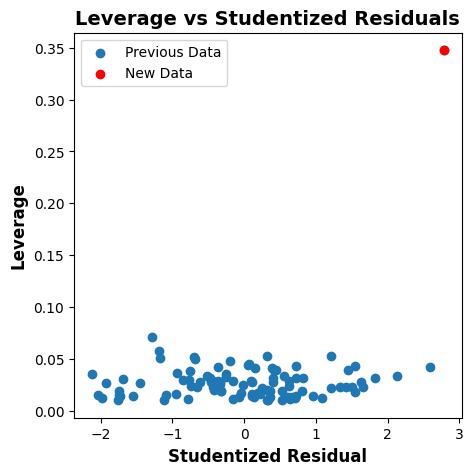

In [382]:
# Influence plot
infl = results.get_influence()
_, ax = subplots(figsize=(5,5))
ax.scatter(
    infl.resid_studentized_external, 
    infl.hat_matrix_diag,
    label='Previous Data'
)
ax.scatter(
    infl.resid_studentized_external[-1],
    infl.hat_matrix_diag[-1],
    color='red',
    label='New Data'
)
ax.set_title('Leverage vs Studentized Residuals', **title_args)
ax.set_xlabel('Studentized Residual', **label_args)
ax.set_ylabel('Leverage', **label_args)
ax.legend();

In [383]:
# High Leverage
leverage_mean = infl.hat_matrix_diag.mean()
leverage_threshold = leverage_mean * 3
leverage_high_list = [x for x in infl.hat_matrix_diag if x > leverage_threshold]

# Outliers
outliers_list = [x for x in infl.resid_studentized_external if abs(x) >= 3]

# Print
print(
f"""
High Leverage: {len(leverage_high_list)}
Outliers:      {len(outliers_list)}
"""
)


High Leverage: 1
Outliers:      0



We see that the new observation is a high-leverage point but is not an outlier. It's leverage value is above 3x the data mean value but its studentized residual is not >= 3. 

##### <u>Linear Regression #2</u>

$$
y = \beta_0 + \beta_1x_1
$$

In [384]:
# Feature matrix with just x1
X1 = X[:, [0,1]]

# Create & fit the model
model = sm.OLS(y, X1)
results = model.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.217
Model:                            OLS   Adj. R-squared:                  0.209
Method:                 Least Squares   F-statistic:                     27.42
Date:                Wed, 27 May 2026   Prob (F-statistic):           9.23e-07
Time:                        14:36:38   Log-Likelihood:                -140.37
No. Observations:                 101   AIC:                             284.7
Df Residuals:                      99   BIC:                             290.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.0739      0.201     10.310      0.000       1.675       2.473
x1             1.8760      0.358      5.236      0.000       1.165       2.587
==============================================================================
Omnibus:                        8.232   Durbin-Watson:                   1.636
Prob(Omnibus):                  0.016   Jarque-Bera (JB):               10.781
Skew:                           0.396   Prob(JB):                      0.00456
Kurtosis:                       4.391   Cond. No.                         4.61
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

The linear model including only the 'intercept' and 'x1' shows an improvement in the estimate of $\beta_1$, it is now closer to the true value and statistically significant. However, the new observation still introduces distortion: both the intercept and $\beta_1$ deviate from their true values when compared to the model estimated without the new observation.


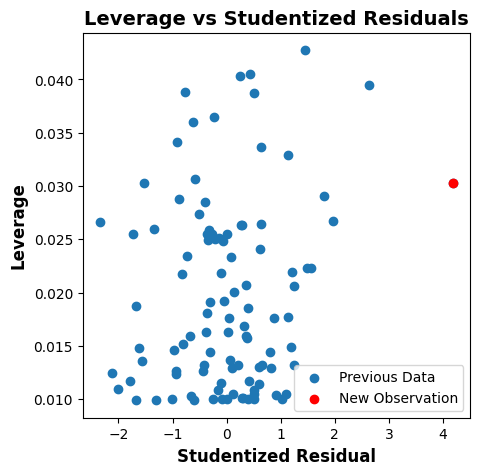

In [385]:
# Get influence
infl = results.get_influence()

# Plot it
ax = subplots(figsize=(5,5))[1]
ax.scatter(
    infl.resid_studentized_external,
    infl.hat_matrix_diag,
    label='Previous Data'
)
ax.scatter(
    infl.resid_studentized_external[-1],
    infl.hat_matrix_diag[-1],
    c='r',
    label='New Observation'
)
ax.set_title('Leverage vs Studentized Residuals', **title_args)
ax.set_ylabel('Leverage', **label_args)
ax.set_xlabel('Studentized Residual', **label_args)
ax.legend();

Although the new observation does not significantly affect the least squares fit, since its leverage is not substantially higher than that of most other observations, it is still an outlier (studentized residuals > 3), which can introduce problems.

For example, this outlier leads to much wider confidence intervals for all coefficients and a noticeable drop in adjusted $R^2$, from 0.274 to 0.209. This is likely due to an increase in the residual standard error (RSE), caused by the outlier's predicted value deviating considerably from its actual value.

##### <u>Linear Regression #3</u>

$$
y = \beta_0 + \beta_2x_2
$$

In [386]:
# Adapt feature matrix
X1 = X[:, [0,2]]

# Create & fit model
model = sm.OLS(y, X1)
results = model.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.267
Model:                            OLS   Adj. R-squared:                  0.260
Method:                 Least Squares   F-statistic:                     36.10
Date:                Wed, 27 May 2026   Prob (F-statistic):           3.13e-08
Time:                        14:36:38   Log-Likelihood:                -137.01
No. Observations:                 101   AIC:                             278.0
Df Residuals:                      99   BIC:                             283.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.2840      0.151     15.088      0.000       1.984       2.584
x1             3.1458      0.524      6.008      0.000       2.107       4.185
==============================================================================
Omnibus:                        0.495   Durbin-Watson:                   1.939
Prob(Omnibus):                  0.781   Jarque-Bera (JB):                0.631
Skew:                          -0.041   Prob(JB):                        0.729
Kurtosis:                       2.621   Cond. No.                         5.84
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

The linear regression model using only the 'intercept' and 'x2' produces an inflated estimate of $\beta_2$, with a value of 3.14, which is far above the true value of 0.3. Additionally, the model appears to offer a better fit compared to the previous model using 'x1', by indicating a higher adjusted $R^2$ of 0.260 versus 0.209. However, since we generated the data, we know that 'x2' is simply 'x1' divived by a factor of 2, and the the response variable 'y' is actually influenced by a coefficient of 0.3 for 'x2' and 2 for 'x1'. Therefore, it is incorrect to conclude that 'x2' provides a better fit for 'y' than 'x1'. This misleading outcome is a results of the new observation, which distorts the model's behaviour.

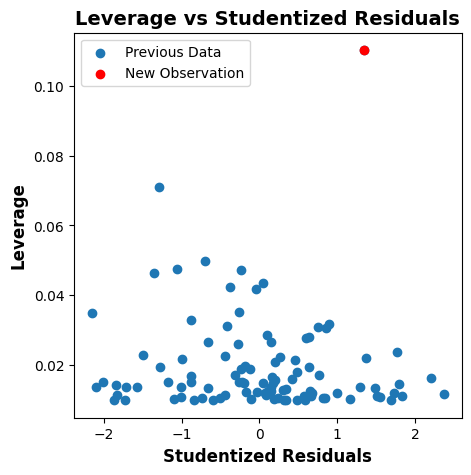

In [387]:
# Get model's influence
infl = results.get_influence()

# Plot
ax = subplots(figsize=(5,5))[1]
ax.scatter(
    infl.resid_studentized_external,
    infl.hat_matrix_diag,
    label='Previous Data'
)
ax.scatter(
    infl.resid_studentized_external[-1],
    infl.hat_matrix_diag[-1],
    label='New Observation',
    c='red'
)
ax.set_title('Leverage vs Studentized Residuals', **title_args)
ax.set_xlabel('Studentized Residuals', **label_args)
ax.set_ylabel('Leverage', **label_args)
ax.legend();

The fact that the new observation has high leverage but is not an outlier in this model helps explain the results. Its high leverage means it has a strong influence on the fitted regression line, which contributes to the overestimation of $\beta_2$. However, since it is not an outlier, it does not inflate the residual standard error (RSE), which affects all confidence intervals. As a result, the model achieves a higher adjusted $R^2$ compared to the previous linear regression using only 'x1'.

---

### Question 15

#### 15a)

In [388]:
# Load Boston dataset
boston = pd.read_csv('data/Boston.csv')

# Quick info
boston.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  506 non-null    int64  
 1   crim        506 non-null    float64
 2   zn          506 non-null    float64
 3   indus       506 non-null    float64
 4   chas        506 non-null    int64  
 5   nox         506 non-null    float64
 6   rm          506 non-null    float64
 7   age         506 non-null    float64
 8   dis         506 non-null    float64
 9   rad         506 non-null    int64  
 10  tax         506 non-null    int64  
 11  ptratio     506 non-null    float64
 12  lstat       506 non-null    float64
 13  medv        506 non-null    float64
dtypes: float64(10), int64(4)
memory usage: 55.5 KB


In [389]:
# Check first observations
boston.head()

,Unnamed: 0,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
0,1,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,2,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,3,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,4,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,5,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2


In [390]:
# Create response variable & feature matrix
y = boston['crim']
X = boston.iloc[:, 2:]
X.insert(0, 'intercept', np.ones(X.shape[0]))

# Loop through features
for feature in X.columns[1:]:
    
    # Create temp feature matrix
    X_ = X[['intercept', feature]]
    
    # Fit & train model
    model = sm.OLS(y, X_)
    results = model.fit()
    print(summarize(results), '\n')

             coef  std err       t  P>|t|
intercept  4.4537    0.417  10.675    0.0
zn        -0.0739    0.016  -4.594    0.0 

             coef  std err      t  P>|t|
intercept -2.0637    0.667 -3.093  0.002
indus      0.5098    0.051  9.991  0.000 

             coef  std err      t  P>|t|
intercept  3.7444    0.396  9.453  0.000
chas      -1.8928    1.506 -1.257  0.209 

              coef  std err       t  P>|t|
intercept -13.7199    1.699  -8.073    0.0
nox        31.2485    2.999  10.419    0.0 

              coef  std err      t  P>|t|
intercept  20.4818    3.364  6.088    0.0
rm         -2.6841    0.532 -5.045    0.0 

             coef  std err      t  P>|t|
intercept -3.7779    0.944 -4.002    0.0
age        0.1078    0.013  8.463    0.0 

             coef  std err       t  P>|t|
intercept  9.4993    0.730  13.006    0.0
dis       -1.5509    0.168  -9.213    0.0 

             coef  std err       t  P>|t|
intercept -2.2872    0.443  -5.157    0.0
rad        0.6179    0.034

When fitting a linear model with just the 'intercept' and one of the features, we get that all features but 'chas' are statistically significant.

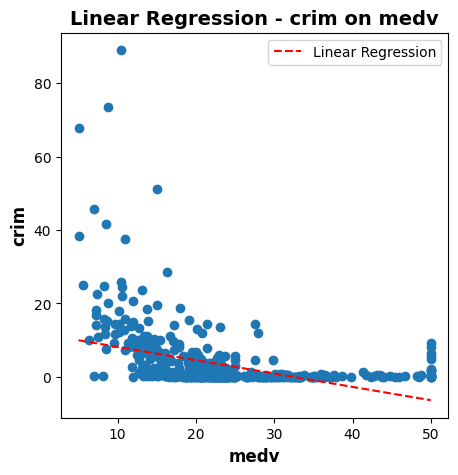

In [391]:
# Range of 'medv' (last feature)
xmin = X['medv'].min()
xmax = X['medv'].max()
xrange = np.linspace(xmin, xmax, 100)
Xrange = np.column_stack((np.ones(len(xrange)), xrange))

# Predict on range for plot
preds = results.predict(Xrange)

# Plot
plt.figure(figsize=(5,5))
plt.scatter(X['medv'], y)
plt.plot(xrange, preds, c='r', ls='--', label='Linear Regression')
plt.title('Linear Regression - crim on medv', **title_args)
plt.xlabel('medv', **label_args)
plt.ylabel('crim', **label_args)
plt.legend();


The plot displays the best linear regression fit to the data. While the model clearly fails to capture or predict the data, it still yields a $\beta_1$ coefficient that is statistically significant. This means that there is a non-random association between 'medv' and 'crim'.

In [392]:
# Create & fit a model for all features
model = sm.OLS(y, X)
results = model.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   crim   R-squared:                       0.449
Model:                            OLS   Adj. R-squared:                  0.436
Method:                 Least Squares   F-statistic:                     33.52
Date:                Wed, 27 May 2026   Prob (F-statistic):           2.03e-56
Time:                        14:36:38   Log-Likelihood:                -1655.4
No. Observations:                 506   AIC:                             3337.
Df Residuals:                     493   BIC:                             3392.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     13.7784      7.082      1.946      0.052      -0.136      27.693
zn             0.0457      0.019      2.433      0.015       0.009       0.083
indus         -0.0584      0.084     -0.698      0.486      -0.223       0.106
chas          -0.8254      1.183     -0.697      0.486      -3.150       1.500
nox           -9.9576      5.290     -1.882      0.060     -20.351       0.436
rm             0.6289      0.607      1.036      0.301      -0.564       1.822
age           -0.0008      0.018     -0.047      0.962      -0.036       0.034
dis           -1.0122      0.282     -3.584      0.000      -1.567      -0.457
rad            0.6125      0.088      6.997      0.000       0.440       0.784
tax           -0.0038      0.005     -0.730      0.466      -0.014       0.006
ptratio       -0.3041      0.186     -1.632      0.103      -0.670       0.062
lstat          0.1388      0.076      1.833      0.067      -0.010       0.288
medv          -0.2201      0.060     -3.678      0.000      -0.338      -0.103
==============================================================================
Omnibus:                      663.436   Durbin-Watson:                   1.516
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            80856.852
Skew:                           6.579   Prob(JB):                         0.00
Kurtosis:                      63.514   Cond. No.                     1.24e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.24e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

#### 15b)

When we incorporate all features/predictors into the model, we get many less coefficients that are statistically significant. This time only 'zn', 'dis', 'rad', and 'medv'.

#### 15c)

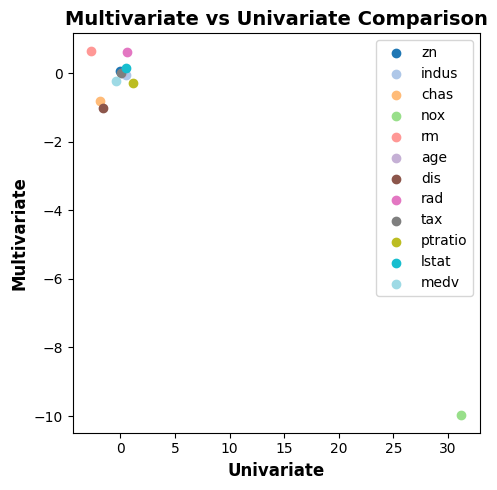

In [393]:
# Initialize a list to store coefficients
coef_list = []

# Capture the univariate coefficients
for feature in X.columns[1:]:
    
    # Create temp feature matrix
    X_ = X[['intercept', feature]]
    
    # Fit & train model
    model = sm.OLS(y, X_)
    results = model.fit()
    coef_list.append(results.params.iloc[1])

# Create & fit a model with all features
model = sm.OLS(y, X)
results = model.fit()

# Store all coefficients in a dataframe
coef_df = pd.DataFrame(index=X.columns[1:])
coef_df['univariate'] = coef_list
coef_df['multivariate'] = results.params[1:]

# Plot
colors = cm.tab20(np.linspace(0, 1, len(coef_df)))
plt.figure(figsize=(5,5))

for i, (feature, row) in enumerate(coef_df.iterrows()):
    plt.scatter(
        row['univariate'], 
        row['multivariate'],
        color=colors[i],
        label=feature
    )
plt.title('Multivariate vs Univariate Comparison', **title_args)
plt.xlabel('Univariate', **label_args)
plt.ylabel('Multivariate', **label_args)
plt.tight_layout()
plt.legend();

We see a cluster of coefficients with relatively similar values/magnitudes, except for the 'nox' coefficient. Its large and different values in both axis skews the scale of the plot, making it difficult to visually compare the remaining coefficients effectively.

#### 15d)

In [394]:
# 3rd degree polynomial
poly = PolynomialFeatures(3)

# Iterate over features
for feature in X.columns[1:]:

    # Create a feature matrix
    X_ = poly.fit_transform(np.asarray(X[feature]).reshape(-1,1))

    # Create & fit model
    model = sm.OLS(y, X_)
    results = model.fit()

    # Print info
    dash = '-' * len(feature)
    print(feature)
    print(dash)
    print(summarize(results), '\n\n')

zn
--
           coef   std err       t  P>|t|
const  4.846100  0.433000  11.192  0.000
x1    -0.332200  0.110000  -3.025  0.003
x2     0.006500  0.004000   1.679  0.094
x3    -0.000038  0.000031  -1.203  0.230 


indus
-----
         coef  std err      t  P>|t|
const  3.6626    1.574  2.327   0.02
x1    -1.9652    0.482 -4.077   0.00
x2     0.2519    0.039  6.407   0.00
x3    -0.0070    0.001 -7.292   0.00 


chas
----
         coef  std err      t  P>|t|
const  3.7444    0.396  9.453  0.000
x1    -0.6309    0.502 -1.257  0.209
x2    -0.6309    0.502 -1.257  0.209
x3    -0.6309    0.502 -1.257  0.209 


nox
---
            coef  std err      t  P>|t|
const   233.0866   33.643  6.928    0.0
x1    -1279.3713  170.397 -7.508    0.0
x2     2248.5441  279.899  8.033    0.0
x3    -1245.7029  149.282 -8.345    0.0 


rm
--
           coef  std err      t  P>|t|
const  112.6246   64.517  1.746  0.081
x1     -39.1501   31.311 -1.250  0.212
x2       4.5509    5.010  0.908  0.364
x3      -0.1745

Several features exhibit statistically significant polynomial terms, indicating non-linear relationships with the response. For example, 'indus', 'nox', 'dis', 'ptratio', and 'medv' have all their polynomial coefficients significant. Interestingly, 'age' shows significance only at the quadratic and cubic levels, but not in its linear form.

These results provide strong evidence of non-linear association between multiple predictors and the response.